# 長短期記憶模型 (Long Short-Term Memory, LSTM)

In [1]:
import numpy as np

# 指定要讀取的文字檔路徑
filename = "data/shakespeare.txt"

# 讀取整個文字檔內容
data = open(filename, "r").read()
# 取得資料中所有不重複字元，建立字元表
chars = list(set(data))
# 計算全文字元總數與不重複字元數量
data_size, vocab_size = len(data), len(chars)

# 輸出資料集的基本統計資訊
print("字元總數 %d, 字符表的長度 %d unique." % (data_size, vocab_size))
# 顯示字元表中的前 10 個字元，方便快速查看字元組成
print("字元表中的前 10 個字元：\n", chars[:10])
# 顯示原始文字前 148 個字元，作為資料內容預覽
print("前 148 個字元：\n", data[:148])

# 建立字元到索引的映射表，方便將文字資料轉成模型可處理的數值表示
char_to_idx = {ch: i for i, ch in enumerate(chars)}

# 建立索引到字元的映射表，方便之後將模型輸出還原成文字
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# 輸出雙向映射內容，確認字元表與索引配置是否正確
print("字元到索引的映射：\n", char_to_idx)
print("索引到字元的映射：\n", idx_to_char)


def one_hot_idx(idx, vocab_size):
    # 建立一個大小為 (1, vocab_size) 的全 0 向量
    x = np.zeros((1, vocab_size))

    # 將指定索引位置設為 1，形成 one-hot 表示
    x[0, idx] = 1

    # 回傳 one-hot 向量
    return x


# 測試 one_hot_idx 函數，將索引 1 轉換為 one-hot 向量
test_idx = 1
one_hot_vector = one_hot_idx(char_to_idx["B"], vocab_size)

# 輸出測試結果
print("索引 %d 的 one-hot 向量：\n" % test_idx, one_hot_vector)

字元總數 1115394, 字符表的長度 65 unique.
字元表中的前 10 個字元：
 ['b', 'A', 'o', ',', 'h', 'V', 'U', 'P', 'T', 'L']
前 148 個字元：
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

字元到索引的映射：
 {'b': 0, 'A': 1, 'o': 2, ',': 3, 'h': 4, 'V': 5, 'U': 6, 'P': 7, 'T': 8, 'L': 9, 'X': 10, '3': 11, 'p': 12, 'k': 13, ' ': 14, '$': 15, 'v': 16, 'x': 17, '!': 18, 's': 19, 'B': 20, 'w': 21, 'r': 22, 'm': 23, '.': 24, 'i': 25, 'E': 26, 'J': 27, 'K': 28, 'e': 29, 'W': 30, 'Z': 31, ';': 32, 'R': 33, 'n': 34, 'y': 35, 'd': 36, 'u': 37, 'Q': 38, 'I': 39, 'a': 40, 'q': 41, 't': 42, "'": 43, 'O': 44, 'g': 45, 'c': 46, '\n': 47, 'f': 48, 'F': 49, 'Y': 50, 'l': 51, 'H': 52, 'j': 53, '-': 54, ':': 55, 'G': 56, '?': 57, 'C': 58, 'z': 59, 'M': 60, '&': 61, 'N': 62, 'D': 63, 'S': 64}
索引到字元的映射：
 {0: 'b', 1: 'A', 2: 'o', 3: ',', 4: 'h', 5: 'V', 6: 'U', 7: 'P', 8: 'T', 9: 'L', 10: 'X', 11: '3', 12: 'p', 13: 'k', 14: ' ', 15: '$', 16: 'v

## 向前傳播

這段程式碼實作的是 LSTM（Long Short-Term Memory）在處理時間序列資料時的向前傳播流程。  

<img src="image/lstm.webp" alt="lstm" style="width: 70%;"/>

<img src="image/lstm-time-series.webp" alt="lstm in time series" style="width: 70%;"/>

圖片來源： https://www.geeksforgeeks.org/deep-learning/deep-learning-introduction-to-long-short-term-memory/

* Forget Gate (遺忘門，以Sigmoid為啟動函數)
    $$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)$$

* Input Gate (輸入門)
    $$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)$$

* Candidate Memory (候選記憶)
    $$\tilde{C}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)$$

* Cell State (單元狀態更新)
    $$C_t = f_t C_{t-1} + i_t \tilde{C}_t$$

* Output Gate (輸出門)
    $$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)$$

* Final Hidden State (最終隱藏狀態)
    $$h_t = o_t \odot \tanh(C_t)$$

* Output Layer (輸出層)
    $$y_t = h_t \cdot W_y + b_y$$


### 總結：LSTM 資料流 (Data Flow)

完整的時間步 ($t$) 運算過程：**輸入** $\rightarrow$ **Gate 運算** $\rightarrow$ **記憶更新** $\rightarrow$ **隱藏狀態輸出** $\rightarrow$ **最終輸出**

$$
(x_t, h_{t-1}) \rightarrow (f_t, i_t, o_t, \tilde{C}_t) \rightarrow C_t \rightarrow h_t \rightarrow y_t
$$

流程拆解：
1. 輸入與隱藏狀態：接收當前輸入 $x_t$ 與前一刻的隱藏狀態 $h_{t-1}$。
2. 門控運算（Gate Mechanism）：同時計算遺忘門 ($f_t$)、輸入門 ($i_t$)、輸出門 ($o_t$) 以及候選記憶 ($\tilde{C}_t$)。
3. 記憶更新（Cell State Update）：利用 $f_t$ 遺忘舊記憶，$i_t$ 寫入新記憶，得到新的單元狀態 $C_t$。
4. 隱藏狀態輸出（Hidden State）：透過 $o_t$ 過濾 $C_t$ 的資訊，輸出當前的隱藏狀態 $h_t$。
5. 最終輸出（Output Layer）：藉由隱藏狀態 $h_t$ 計算最終輸出 $y_t$。

In [1]:
def sigmoid(x):
    # sigmoid 啟用函式
    return 1 / (1 + np.exp(-x))


def lstm_forward(params, Xs, state):
    # 取出所有 LSTM 與輸出層參數
    [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by] = params

    # 初始 hidden state 與 cell state
    (H, C) = state  # 初始状态

    # 儲存每個時間步的 hidden state 與 cell state
    Hs = {}
    Cs = {}

    # 儲存每個時間步的輸出結果
    Zs = []

    # 額外保留初始狀態，方便後續存取
    Hs[-1] = np.copy(H)
    Cs[-1] = np.copy(C)

    # 儲存每個時間步的 gate 與候選 cell 結果
    Is = []
    Fs = []
    Os = []
    C_tildas = []

    # 逐時間步處理輸入序列
    for t in range(len(Xs)):
        X = Xs[t]

        # 將當前輸入與前一時刻 hidden state 串接，例如：X = [1, 2, 3] , H = [0.5, 0.8]  => XH = [[1, 2, 3, 0.5, 0.8]]
        XH = np.column_stack((X, H))

        # 除錯用區塊，目前不會執行
        if False:
            print("XH.shape", XH.shape)
            print("Wi.shape", Wi.shape)
            break

        # 計算三個 gate 與候選 cell 狀態
        I = sigmoid(np.dot(XH, Wi) + bi)
        F = sigmoid(np.dot(XH, Wf) + bf)
        O = sigmoid(np.dot(XH, Wo) + bo)
        C_tilda = np.tanh(np.dot(XH, Wc) + bc)

        # 更新 cell state
        C = F * C + I * C_tilda

        # 更新 hidden state
        H = O * np.tanh(C)  # O * C.tanh()  #输出状态

        # 經輸出層得到當前時間步輸出
        Y = np.dot(H, Wy) + by  # 输出

        # 紀錄當前時間步結果
        Zs.append(Y)
        Hs[t] = H
        Cs[t] = C

        # 紀錄各 gate 與候選 cell 結果
        Is.append(I)
        Fs.append(F)
        Os.append(O)
        C_tildas.append(C_tilda)

    # 回傳整段序列輸出、各時間步狀態，以及中間 gate 結果
    return Zs, Hs, Cs, (Is, Fs, Os, C_tildas)


def lstm_forward_step(params, X, H, C):
    # 取出所有 LSTM 與輸出層參數
    [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by] = params

    # 將當前輸入與前一時刻 hidden state 串接
    XH = np.column_stack((X, H))

    # 計算三個 gate 與候選 cell 狀態
    I = sigmoid(np.dot(XH, Wi) + bi)
    F = sigmoid(np.dot(XH, Wf) + bf)
    O = sigmoid(np.dot(XH, Wo) + bo)
    C_tilda = np.tanh(np.dot(XH, Wc) + bc)

    # 更新 cell state 與 hidden state
    C = F * C + I * C_tilda
    H = O * np.tanh(C)  # O * tanh(C)  #输出状态

    # 經輸出層得到單一步驟輸出
    Y = np.dot(H, Wy) + by  # 输出

    # 回傳輸出、更新後狀態，以及當前步驟的 gate 結果
    return Y, H, C, (I, F, O, C_tilda)

## 反向傳播

這段程式碼實作的是 LSTM 在整段序列上的反向傳播，也就是BPTT（Backpropagation Through Time），將已知每個時間步輸出端傳回來的梯度 \(dZ_t\)，反推出所有參數的梯度，包含：

- LSTM 前向傳播公式
- 鏈式法則（Chain Rule）
- 四個 Gate 的梯度拆解
- 時間反向傳播（BPTT）
- 梯度裁切（Gradient Clipping）

### 啟動函數與導數

#### 1. Sigmoid

$$\sigma(x)=\frac{1}{1+e^{-x}}$$
$$\frac{d}{dx}\sigma(x)=\sigma(x)(1-\sigma(x))$$

#### 2. Tanh

$$\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}$$
$$\frac{d}{dx}\tanh(x)=1-\tanh^2(x)$$

### LSTM 前向傳播

#### 1. Gate 計算

$$
\begin{aligned}
i_t &= \sigma(W_i [x_t, h_{t-1}] + b_i) \\
f_t &= \sigma(W_f [x_t, h_{t-1}] + b_f) \\
o_t &= \sigma(W_o [x_t, h_{t-1}] + b_o) \\
\tilde{C}_t &= \tanh(W_c [x_t, h_{t-1}] + b_c)
\end{aligned}
$$

#### 2. Cell State 更新

$$C_t = f_t C_{t-1} + i_t \tilde{C}_t$$

#### 3. Hidden State

$$h_t = o_t \tanh(C_t)$$

### 反向傳播（BPTT）

#### 1. Hidden State 梯度

$$dH_t = dZ_t W_y^T + dH_{t+1}$$

#### 2. Cell State 梯度

$$dC_t = dH_t \cdot o_t \cdot (1 - \tanh^2(C_t)) + dC_{t+1}$$

#### 3. Output Gate

$$
\begin{aligned}
dO_t &= \tanh(C_t) \cdot dH_t \\
dZ_o &= o_t (1 - o_t) \cdot dO_t
\end{aligned}
$$

#### 4. Input Gate

$$
\begin{aligned}
d i_t &= \tilde{C}_t \cdot dC_t \\
dZ_i &= i_t (1 - i_t) \cdot d i_t
\end{aligned}
$$

#### 5. Forget Gate

$$
\begin{aligned}
d f_t &= C_{t-1} \cdot dC_t \\
dZ_f &= f_t (1 - f_t) \cdot d f_t
\end{aligned}
$$

#### 6. Candidate Cell

$$
\begin{aligned}
d\tilde{C}_t &= i_t \cdot dC_t \\
dZ_c &= (1 - \tilde{C}_t^2) \cdot d\tilde{C}_t
\end{aligned}
$$

#### 7. Cell State 傳遞

$$dC_{t-1} = f_t \cdot dC_t$$

### 參數梯度

#### 1. 權重（以 output gate 為例）

$$dW_o = [x_t, h_{t-1}]^T \cdot dZ_o$$

#### 2. 偏置

$$db_o = \sum dZ_o$$

### 梯度裁切（Gradient Clipping）

#### 1. L2 Norm

$$\|g\|_2 = \sqrt{\sum_i g_i^2}$$

#### 2. 梯度縮放

$$g \leftarrow g \cdot \frac{\alpha}{\|g\|}, \quad \text{if } \|g\| > \alpha$$

In [3]:
import math


def dsigmoid(x):
    # sigmoid 的導數
    return sigmoid(x) * (1 - sigmoid(x))


def dtanh(x):
    # tanh 的導數
    return 1 - np.tanh(x) * np.tanh(x)


def grad_clipping(grads, alpha):
    # 計算所有梯度的整體 L2 norm
    norm = math.sqrt(sum((grad**2).sum() for grad in grads))

    # 若超過門檻，則按比例縮放所有梯度
    if norm > alpha:
        ratio = alpha / norm
        for i in range(len(grads)):
            grads[i] *= ratio


def lstm_backward(params, Xs, Hs, Cs, dZs, cache, clip_value=5.0):  # Ys,loss_function):
    # 取出 LSTM 與輸出層參數
    [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by] = params

    # 取出前向傳播保留的 gate 與候選 cell 結果
    Is, Fs, Os, C_tildas = cache

    # 初始化各參數梯度
    dWi, dWf, dWo, dWc, dWy = (
        np.zeros_like(Wi),
        np.zeros_like(Wf),
        np.zeros_like(Wo),
        np.zeros_like(Wc),
        np.zeros_like(Wy),
    )
    dbi, dbf, dbo, dbc, dby = (
        np.zeros_like(bi),
        np.zeros_like(bf),
        np.zeros_like(bo),
        np.zeros_like(bc),
        np.zeros_like(by),
    )

    # 初始化從下一時間步回傳的 hidden state 與 cell state 梯度
    dH_next = np.zeros_like(Hs[0])
    dC_next = np.zeros_like(Cs[0])

    # 取得輸入特徵維度，用於後續拆分 dXH_
    input_dim = Xs[0].shape[1]

    # 簡化變數名稱
    h = Hs
    x = Xs

    # 序列長度
    T = len(Xs)

    # 依時間反向走訪
    for t in reversed(range(T)):
        # 取出當前時間步前向傳播保存的中間結果
        I = Is[t]
        F = Fs[t]
        O = Os[t]
        C_tilda = C_tildas[t]
        H = Hs[t]
        X = Xs[t]
        C = Cs[t]
        H_pre = Hs[t - 1]
        C_prev = Cs[t - 1]

        # 將當前輸入與前一時刻 hidden state 串接
        XH_pre = np.column_stack((X, H_pre))
        XH_ = XH_pre

        # 當前時間步來自輸出端的梯度
        dZ = dZs[t]

        # 輸出層參數梯度
        dWy += np.dot(H.T, dZ)
        dby += np.sum(dZ, axis=0, keepdims=True)

        # hidden state 的總梯度
        # 包含目前輸出層傳回的梯度，以及下一時間步回傳的梯度
        dH = np.dot(dZ, Wy.T) + dH_next

        # cell state 的總梯度
        dC = dH * O * dtanh(C) + dC_next  # H_t= O_t*tanh(C_t)

        # output gate 梯度
        dO = np.tanh(C) * dH
        dOZ = O * (1 - O) * dO  # O = sigma(Z_o)
        dWo += np.dot(XH_.T, dOZ)  # Z_o = (X,H_)W_o+b_o
        dbo += np.sum(dOZ, axis=0, keepdims=True)

        # input gate 梯度
        di = C_tilda * dC
        diZ = I * (1 - I) * di
        dWi += np.dot(XH_.T, diZ)
        dbi += np.sum(diZ, axis=0, keepdims=True)

        # forget gate 梯度
        df = C_prev * dC
        dfZ = F * (1 - F) * df
        dWf += np.dot(XH_.T, dfZ)
        dbf += np.sum(dfZ, axis=0, keepdims=True)

        # 候選 cell 狀態梯度
        dC_tilda = I * dC  # C = F * C + I * C_tilda
        dC_tilda_Z = (1 - np.square(C_tilda)) * dC_tilda  # C_tilda = tanh(C_tilda_Z)
        dWc += np.dot(XH_.T, dC_tilda_Z)  # C_tilda_Z = (X,H_)W_c+b_c
        dbc += np.sum(dC_tilda_Z, axis=0, keepdims=True)

        # 將各 gate 傳回輸入與前一 hidden state 的梯度合併
        dXH_ = (
            np.dot(dfZ, Wf.T)
            + np.dot(diZ, Wi.T)
            + np.dot(dC_tilda_Z, Wc.T)
            + np.dot(dOZ, Wo.T)
        )

        # 拆出對輸入與前一 hidden state 的梯度
        dX_prev = dXH_[:, :input_dim]
        dH_prev = dXH_[:, input_dim:]

        # 傳回前一 cell state 的梯度
        dC_prev = F * dC

        # 更新傳給前一時間步的梯度
        dC_next = dC_prev
        dH_next = dH_prev

    # 整理所有參數梯度
    grads = [dWi, dbi, dWf, dbf, dWo, dbo, dWc, dbc, dWy, dby]

    # 做梯度裁切，避免梯度爆炸
    grad_clipping(grads, clip_value)

    # for dparam in [dWi, dbi,dWf, dbf, dWo,dbo,dWc, dbc,dWy,dby]:
    #    np.clip(dparam, -5, 5, out=dparam) # clip to mitigate exploding gradients

    return grads

## 初始化

In [4]:
import numpy as np


def lstm_params_init(input_dim, hidden_dim, output_dim, scale=0.01):
    # 建立常態分布隨機初始化函式，用於產生權重矩陣
    normal = lambda m, n: np.random.randn(m, n) * scale

    # 建立單一 gate 的權重與偏置
    # 權重輸入維度為 input_dim + hidden_dim，輸出維度為 hidden_dim
    two = lambda: (
        normal(input_dim + hidden_dim, hidden_dim),
        np.zeros((1, hidden_dim)),
    )

    # 各 gate 參數初始化
    Wi, bi = two()  # Input gate parameters
    Wf, bf = two()  # Forget gate parameters
    Wo, bo = two()  # Output gate parameters
    Wc, bc = two()  # Candidate cell parameters

    # 輸出層參數初始化
    Wy = normal(hidden_dim, output_dim)
    by = np.zeros((1, output_dim))

    # 依固定順序整理所有參數，供前向傳播函式使用
    params = [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by]
    return params


def lstm_state_init(batch_size, hidden_size):
    # 初始化隱藏狀態 H 與記憶狀態 C
    return (np.zeros((batch_size, hidden_size)), np.zeros((batch_size, hidden_size)))

## 測試前向與反向傳播是否正確

In [5]:
import modules.rnn as fr  # 匯入自定義 RNN 模組，並使用 fr 作為別名
import modules.util as util  # 匯入工具模組，並使用 util 作為別名

# 設定序列長度、輸入維度、隱藏層維度、輸出維度與 batch size
T = 3
input_dim, hidden_dim, output_dim = 4, 3, 4
batch_size = 2

# 建立隨機輸入序列，形狀為 (T, batch_size, input_dim)
Xs = np.random.randn(T, batch_size, input_dim)

# 建立隨機標籤，形狀為 (T, batch_size)
Ys = np.random.randint(output_dim, size=(T, batch_size))

# 印出測試資料
print("Xs", Xs)
print("Ys", Ys)

# gradient check 前的參數與狀態初始化
params = lstm_params_init(input_dim, hidden_dim, output_dim)
HC = lstm_state_init(batch_size, hidden_dim)

# 前向傳播，取得輸出、各時間步狀態與快取資料
Zs, Hs, Cs, cache = lstm_forward(params, Xs, HC)

# 透過 loss function 計算 loss 與輸出端梯度
loss_function = fr.rnn_loss_grad
loss, dZs = loss_function(Zs, Ys)

# 反向傳播，取得解析梯度
grads = lstm_backward(params, Xs, Hs, Cs, dZs, cache)


def rnn_loss():
    # 重新初始化狀態，避免前次執行結果影響 loss 計算
    HC = lstm_state_init(batch_size, hidden_dim)

    # 重新執行前向傳播
    Zs, Hs, Cs, cache = lstm_forward(params, Xs, HC)

    # 重新計算 loss
    loss_function = fr.rnn_loss_grad
    loss, dZs = loss_function(Zs, Ys)
    return loss


# 使用數值微分計算各參數的梯度，作為 gradient check 依據
numerical_grads = util.numerical_gradient(
    rnn_loss, params, 1e-6
)  # rnn_numerical_gradient(rnn_loss,params,1e-10)

# 定義最大絕對誤差
# diff_error = lambda x, y: np.max( np.abs(x - y)/(np.maximum(1e-8, np.abs(x) + np.abs(y))))
diff_error = lambda x, y: np.max(np.abs(x - y))


def rel_error(x, y):
    """returns relative error"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))


# 印出 loss
print("loss", loss)

# 印出各組參數梯度的誤差
print("[Wi, bi,Wf, bf, Wo,bo,Wc, bc,Wy,by] ")
for i in range(len(grads)):
    print(diff_error(grads[i], numerical_grads[i]))

# 額外印出第一組權重梯度與其數值梯度，方便比對
print("grads", grads[0])
print("numerical_grads", numerical_grads[0])

Xs [[[ 1.62434536 -0.61175641 -0.52817175 -1.07296862]
  [ 0.86540763 -2.3015387   1.74481176 -0.7612069 ]]

 [[ 0.3190391  -0.24937038  1.46210794 -2.06014071]
  [-0.3224172  -0.38405435  1.13376944 -1.09989127]]

 [[-0.17242821 -0.87785842  0.04221375  0.58281521]
  [-1.10061918  1.14472371  0.90159072  0.50249434]]]
Ys [[1 3]
 [1 2]
 [3 0]]
loss 4.158913662271732
[Wi, bi,Wf, bf, Wo,bo,Wc, bc,Wy,by] 
4.988288073824927e-10
3.187698554541755e-10
5.711411932771236e-10
6.160825818152219e-10
6.283187913778661e-10
5.112720486913228e-10
4.7818072982167e-10
4.537810481108212e-10
5.902554806687041e-10
3.0616906232516783e-10
grads [[ 8.61940825e-06  1.70883467e-06 -2.29943867e-05]
 [-2.29317982e-05 -1.62971055e-06  1.72676150e-05]
 [ 8.29013993e-06  5.41013374e-07  1.57553164e-05]
 [ 6.10534894e-07 -7.58508131e-07 -7.99780425e-06]
 [-1.33084038e-08  4.29808615e-09  1.45140399e-07]
 [ 7.49477697e-09  2.52876851e-09  1.55018799e-07]
 [ 3.00999162e-08 -1.28584668e-08 -5.74805034e-07]]
numerical_g

## 訓練函式

In [6]:
def lstm_train_epoch(
    params, data_iter, optimizer, iterations, loss_function, print_n=100
):
    # 取出 LSTM 與輸出層參數
    Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by = params

    # 紀錄每次迭代的 loss
    losses = []

    # 迭代計數器
    iter = 0

    batch_size = None

    # 由輸出層權重推得 hidden state 維度
    hidden_size = Wy.shape[0]

    # 先將狀態設為 None，避免未初始化就使用
    HC = None

    # 逐批次讀取資料
    for Xs, Ys, start in data_iter:
        # 第一次進來時，從輸入資料推得 batch size
        if batch_size is None:
            batch_size = Xs[0].shape[0]

        # 若為新序列起點，或目前尚未有狀態，則初始化 hidden state 與 cell state
        if start or HC is None:
            HC = lstm_state_init(batch_size, hidden_size)

        # 前向傳播
        Zs, Hs, Cs, cache = lstm_forward(params, Xs, HC)

        # 計算 loss 與輸出端梯度
        loss, dZs = loss_function(Zs, Ys)

        # 反向傳播，取得各參數梯度
        grads = lstm_backward(params, Xs, Hs, Cs, dZs, cache)

        # 使用 optimizer 更新參數
        optimizer.step(grads)

        # 將最後一個時間步的狀態保存下來，供下一個 batch 延續使用
        HC = (Hs[len(Xs) - 1], Cs[len(Xs) - 1])

        # 紀錄當前 loss
        losses.append(loss)

        # 依指定間隔印出訓練資訊
        if iter % print_n == 0:
            print("iter %d, loss: %f" % (iter, loss))

        iter += 1

        # 超過指定迭代次數後停止
        if iter > iterations:
            break

    # 回傳整個 epoch 的 loss 與最後狀態
    return losses, HC

In [7]:
def character_seq_data_iter_consecutive(
    data, batch_size, seq_len, vocab_size, start_range=10
):
    # 隨機決定本輪資料切分的起始偏移，讓不同 epoch 的切法略有變化
    start = np.random.randint(0, start_range)

    # 計算每個 batch block 可使用的有效資料長度
    # -1 是因為標籤 Y 需要對應到下一個字元
    block_len = (len(data) - start - 1) // batch_size

    # 計算每個 block 最多可切出幾個完整的 seq_len 批次
    num_batches = block_len // seq_len

    # 建立每個 block 在原始資料中的起始偏移量
    bs = np.array(range(0, block_len * batch_size, block_len))

    # 可實際使用的總時間步數，避免超出完整批次範圍
    i_end = num_batches * seq_len

    # 依 seq_len 為單位，逐段取出固定長度的連續序列
    for i in range(0, i_end, seq_len):
        # 本批次在原始資料中的起始位置
        s = start + i

        # X: 輸入序列，使用 one-hot 表示字元
        # shape = (seq_len, batch_size, vocab_size)
        X = np.empty((seq_len, batch_size, vocab_size), dtype=np.int32)

        # Y: 目標序列，儲存下一個字元的索引
        # shape = (seq_len, batch_size, 1)
        Y = np.empty((seq_len, batch_size, 1), dtype=np.int32)

        # 逐一處理 batch 中的每個樣本
        for b in range(batch_size):
            # 取得第 b 個 block 在本批次中的起始位置
            s_b = s + bs[b]

            # 依時間步填入輸入 X 與標籤 Y
            for t in range(seq_len):
                # 目前字元轉為索引後，再轉成 one-hot 向量作為輸入
                X[t, b, :] = one_hot_idx(char_to_idx[data[s_b]], vocab_size)

                # 下一個字元的索引作為預測目標
                Y[t, b, :] = char_to_idx[data[s_b + 1]]

                # 往下一個時間步前進
                s_b += 1

        # 第一個 batch 額外回傳 True，供外部流程判斷是否為起始批次
        if i == 0:
            yield X, Y, True
        else:
            yield X, Y, False

## 設定並執行 LSTM 模型

iter 0, loss: 104.359723
iter 10, loss: 97.552467
iter 20, loss: 86.703085
iter 30, loss: 83.935824
iter 40, loss: 81.109795
iter 50, loss: 83.350470
iter 60, loss: 77.506128
iter 70, loss: 78.049583
iter 80, loss: 77.112758
iter 90, loss: 75.537452
iter 100, loss: 78.504771
iter 110, loss: 74.180514
iter 120, loss: 79.440131
iter 130, loss: 89.473255
iter 140, loss: 72.602138
iter 150, loss: 82.858332
iter 160, loss: 71.297017
iter 170, loss: 76.570608
iter 180, loss: 85.267331
iter 190, loss: 81.267338
iter 200, loss: 77.861880
iter 210, loss: 73.928954
iter 220, loss: 81.407560
iter 230, loss: 78.826524
iter 240, loss: 71.924502
iter 250, loss: 71.240170
iter 260, loss: 70.718311
iter 270, loss: 81.831017
iter 280, loss: 72.857615
iter 290, loss: 66.085268
iter 300, loss: 71.974290
iter 310, loss: 70.699630
iter 320, loss: 78.774302
iter 330, loss: 66.259577
iter 340, loss: 90.384968
iter 350, loss: 58.004579
iter 360, loss: 69.944577
iter 370, loss: 68.702808
iter 380, loss: 66.055

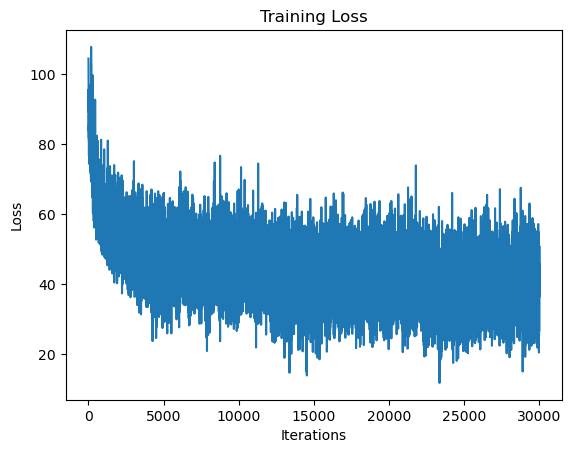

In [8]:
import matplotlib.pyplot as plt

# 設定模型輸入維度、隱藏層維度與輸出維度
# 這裡輸入與輸出都以 vocab_size 為基準，適合字元級模型
input_dim, hidden_dim, output_dim = vocab_size, 100, vocab_size

# 設定 batch size
batch_size = 2

# 初始化 LSTM 參數
params = lstm_params_init(input_dim, hidden_dim, output_dim)

# 初始化 LSTM 狀態
H = lstm_state_init(batch_size, hidden_dim)

# 每段訓練序列的長度
seq_length = 25

# 設定 loss function，回傳 loss 與對輸出層的梯度
loss_function = lambda F, Y: fr.rnn_loss_grad(F, Y)  # ,util.loss_grad_least)

# 設定訓練回合數
epoches = 3

# 設定學習率
learning_rate = 1e-2

# 每個 epoch 允許的最大迭代次數
iterations = 10000

# 用來累積整體訓練過程中的 loss
losses = []

# 建立 AdaGrad optimizer
optimizer = fr.AdaGrad(params, learning_rate)

# 設定 momentum
momentum = 0.9

# 改用 SGD optimizer，並帶入 momentum
# 此行會覆蓋前面建立的 AdaGrad optimizer
optimizer = fr.SGD(params, learning_rate, momentum)

# 逐個 epoch 執行訓練
for epoch in range(epoches):
    # 建立連續字元序列資料迭代器
    data_it = character_seq_data_iter_consecutive(
        data, batch_size, seq_length, vocab_size, 100
    )

    # epoch_losses,param,H = rnn_train(params,data_it,learning_rate,iterations,loss_function,print_n=100)

    # 執行單一 epoch 的 LSTM 訓練
    epoch_losses, H = lstm_train_epoch(
        params, data_it, optimizer, iterations, loss_function, print_n=10
    )

    # 累加本 epoch 的所有 loss
    losses.extend(epoch_losses)

    # epoch_losses = np.array(epoch_losses).mean()
    # losses.append(epoch_losses)

# ===== 繪製訓練 loss 曲線 =====
plt.plot(losses[:])
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

## 文字生成

In [9]:
def predict_lstm(params, prefix, n):
    # 取出 LSTM 與輸出層參數
    Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by = params

    # 由參數形狀推回詞彙大小與 hidden state 維度
    vocab_size, hidden_dim = Wi.shape[0] - Wy.shape[0], Wy.shape[0]

    # 初始化單筆預測時使用的 hidden state 與 cell state
    h, c = lstm_state_init(1, hidden_dim)

    # 先放入 prefix 的第一個字元索引，作為生成起點
    output = [char_to_idx[prefix[0]]]

    # 總共跑 prefix 長度加上欲生成長度，再扣掉已放入的第一個字元
    for t in range(len(prefix) + n - 1):
        # 將上一時間步的輸出字元轉成 one-hot，作為目前時間步輸入
        x = one_hot_idx(output[-1], vocab_size)

        # 執行單一步驟前向傳播，更新輸出與狀態
        z, h, c, _ = lstm_forward_step(params, x, h, c)

        # 在 prefix 範圍內時，直接使用 prefix 的下一個字元
        if t < len(prefix) - 1:
            output.append(char_to_idx[prefix[t + 1]])
        else:
            # 將輸出轉成機率分布
            p = np.exp(z) / np.sum(np.exp(z))

            # idx = int(p.argmax(axis=1))

            # 依機率分布隨機取樣下一個字元
            idx = np.random.choice(range(vocab_size), p=p.ravel())
            output.append(idx)

    # 將索引序列轉回字元字串
    return "".join([idx_to_char[i] for i in output])

In [10]:
str = predict_lstm(params, "he", 500)
print(str)

herptech for a dawbetch
To urpuse I change Buin is id the death by my heart.

D:
Tell have see his honour cussivions in horse in
Fooks o'trieve timition of Clarence!
At blood made for you well sake,
Out were when you say Henritor, Father;
Which and by hishift change:
I'll bear undigidies for my depilia Indivisingest
Take purposen creep you word, both cisivisen,
Uptas o hold unted mine.

CLILFLLRma:
His rowney hip'ly a
channy fathan's the werd of Edward
His that where I shall k;on his cousin;
More 


# LSTM 的 BPTT 核心數學公式（可直接貼上渲染）

> 目標：先簡單複習 LSTM 的 forward，再從 Output Layer 開始做 BPTT（Backpropagation Through Time）完整推導。  
> 記號以向量形式表示，$\odot$ 表示逐元素相乘。

---

## 0) 符號定義

在時間步 $t$：

- 輸入：$x_t$
- 前一個 hidden state：$h_{t-1}$
- 前一個 cell state：$C_{t-1}$

若採用「分開權重」寫法（你指定的形式）：

- forget gate: $(W_f, U_f, b_f)$
- input gate: $(W_i, U_i, b_i)$
- output gate: $(W_o, U_o, b_o)$
- candidate cell: $(W_c, U_c, b_c)$

輸出層：

- $(W_y, b_y)$

---

## 1) LSTM Forward（向前傳播）

### 1.1 Forget gate
$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

### 1.2 Input gate
$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

### 1.3 Output gate
$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

### 1.4 Candidate cell（候選記憶）
$$
\tilde{C}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)
$$

### 1.5 Cell state 更新（核心）
$$
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
$$

### 1.6 Hidden state（輸出）
$$
h_t = o_t \odot \tanh(C_t)
$$

### 1.7 Output layer（以分類為例）
先定義 logits：
$$
z_t = W_y h_t + b_y
$$

機率輸出：
$$
y_t = \mathrm{softmax}(z_t)
$$

若真實標籤為 one-hot 向量 $\hat{y}_t$，則交叉熵 loss：
$$
L_t = -\sum_k \hat{y}_{t,k}\log y_{t,k}
$$

總 loss：
$$
L = \sum_{t=1}^{T} L_t
$$

---

## 2) 會用到的基本導數

### 2.1 Sigmoid 導數
$$
\sigma'(x) = \sigma(x)\bigl(1-\sigma(x)\bigr)
$$

### 2.2 Tanh 導數
$$
\frac{d}{dx}\tanh(x) = 1-\tanh^2(x)
$$

---

## 3) 從 Output Layer 開始 Backward（BPTT）

### 3.1 Softmax + Cross Entropy 的梯度

令
$$
\delta^y_t \equiv \frac{\partial L_t}{\partial z_t}
$$

則有：
$$
\delta^y_t = y_t - \hat{y}_t
$$

### 3.2 對輸出層參數與 hidden 的梯度

對 $W_y$：
$$
\frac{\partial L_t}{\partial W_y} = \delta^y_t h_t^T
$$

對 $b_y$：
$$
\frac{\partial L_t}{\partial b_y} = \delta^y_t
$$

對 $h_t$（只看當前時間步輸出層）：
$$
\frac{\partial L_t}{\partial h_t} = W_y^T \delta^y_t
$$

但在 BPTT 中，$h_t$ 也會影響未來時間步，所以定義總梯度：
$$
\delta^h_t \equiv \frac{\partial L}{\partial h_t}
$$

實際上：
$$
\delta^h_t = W_y^T\delta^y_t + \delta^{h,\text{future}}_t
$$

其中 $\delta^{h,\text{future}}_t$ 是從未來時間步回傳的 hidden 梯度。

---

## 4) 從 $h_t$ 回傳到 $o_t$ 與 $C_t$

由
$$
h_t = o_t \odot \tanh(C_t)
$$

### 4.1 對 output gate 的梯度
$$
\frac{\partial L}{\partial o_t}
= \frac{\partial L}{\partial h_t} \odot \frac{\partial h_t}{\partial o_t}
= \delta^h_t \odot \tanh(C_t)
$$

定義：
$$
\delta^o_t \equiv \frac{\partial L}{\partial o_t}
$$

所以：
$$
\delta^o_t = \delta^h_t \odot \tanh(C_t)
$$

### 4.2 由 $h_t$ 傳到 $C_t$ 的梯度
$$
\frac{\partial h_t}{\partial C_t}
= o_t \odot \bigl(1-\tanh^2(C_t)\bigr)
$$

因此：
$$
\frac{\partial L}{\partial C_t}
= \frac{\partial L}{\partial h_t} \odot \frac{\partial h_t}{\partial C_t}
= \delta^{C,(h)}_t
= \delta^h_t \odot o_t \odot \bigl(1-\tanh^2(C_t)\bigr)
$$

---

## 5) Cell state 的總梯度（LSTM 最關鍵）

因為 $C_t$ 也會影響下一步的 $C_{t+1}$：
$$
C_{t+1} = f_{t+1}\odot C_t + i_{t+1}\odot \tilde{C}_{t+1}
$$

所以 $C_t$ 的總梯度包含兩部分：

1. 當前 $h_t$ 傳回來的  
2. 未來 $C_{t+1}$ 傳回來的

定義：
$$
\delta^C_t \equiv \frac{\partial L}{\partial C_t}
$$

則：
$$
\delta^C_t=
\delta^h_t \odot o_t \odot \bigl(1-\tanh^2(C_t)\bigr)
+
\delta^C_{t+1}\odot f_{t+1}
$$

這條就是 LSTM BPTT 的核心式。

---

## 6) 從 $C_t$ 分流到 forget/input/candidate

由
$$
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
$$

### 6.1 Forget gate 的梯度
$$
\delta^f_t \equiv \frac{\partial L}{\partial f_t}
= \delta^C_t \odot C_{t-1}
$$

### 6.2 Input gate 的梯度
$$
\delta^i_t \equiv \frac{\partial L}{\partial i_t}
= \delta^C_t \odot \tilde{C}_t
$$

### 6.3 Candidate cell 的梯度
$$
\delta^{\tilde{C}}_t \equiv \frac{\partial L}{\partial \tilde{C}_t}
= \delta^C_t \odot i_t
$$

### 6.4 對前一個 cell state 的梯度
$$
\delta^C_{t-1} = \delta^C_t \odot f_t
$$

---

## 7) 回到各 gate 的 pre-activation（乘上 activation 導數）

定義各 gate 的 pre-activation：

$$
a^f_t = W_f x_t + U_f h_{t-1} + b_f
$$
$$
a^i_t = W_i x_t + U_i h_{t-1} + b_i
$$
$$
a^o_t = W_o x_t + U_o h_{t-1} + b_o
$$
$$
a^c_t = W_c x_t + U_c h_{t-1} + b_c
$$

且
$$
f_t=\sigma(a^f_t),\quad i_t=\sigma(a^i_t),\quad o_t=\sigma(a^o_t),\quad \tilde{C}_t=\tanh(a^c_t)
$$

### 7.1 Forget gate pre-activation 梯度
$$
\delta^{a_f}_t \equiv \frac{\partial L}{\partial a^f_t}
= \delta^f_t \odot f_t \odot (1-f_t)
$$

### 7.2 Input gate pre-activation 梯度
$$
\delta^{a_i}_t \equiv \frac{\partial L}{\partial a^i_t}
= \delta^i_t \odot i_t \odot (1-i_t)
$$

### 7.3 Output gate pre-activation 梯度
$$
\delta^{a_o}_t \equiv \frac{\partial L}{\partial a^o_t}
= \delta^o_t \odot o_t \odot (1-o_t)
$$

### 7.4 Candidate cell pre-activation 梯度
$$
\delta^{a_c}_t \equiv \frac{\partial L}{\partial a^c_t}
= \delta^{\tilde{C}}_t \odot \bigl(1-\tilde{C}_t^2\bigr)
$$

---

## 8) 對參數 $W, U, b$ 的梯度

### 8.1 Forget gate 參數
$$
\frac{\partial L}{\partial W_f} = \sum_t \delta^{a_f}_t x_t^T
$$
$$
\frac{\partial L}{\partial U_f} = \sum_t \delta^{a_f}_t h_{t-1}^T
$$
$$
\frac{\partial L}{\partial b_f} = \sum_t \delta^{a_f}_t
$$

### 8.2 Input gate 參數
$$
\frac{\partial L}{\partial W_i} = \sum_t \delta^{a_i}_t x_t^T
$$
$$
\frac{\partial L}{\partial U_i} = \sum_t \delta^{a_i}_t h_{t-1}^T
$$
$$
\frac{\partial L}{\partial b_i} = \sum_t \delta^{a_i}_t
$$

### 8.3 Output gate 參數
$$
\frac{\partial L}{\partial W_o} = \sum_t \delta^{a_o}_t x_t^T
$$
$$
\frac{\partial L}{\partial U_o} = \sum_t \delta^{a_o}_t h_{t-1}^T
$$
$$
\frac{\partial L}{\partial b_o} = \sum_t \delta^{a_o}_t
$$

### 8.4 Candidate cell 參數
$$
\frac{\partial L}{\partial W_c} = \sum_t \delta^{a_c}_t x_t^T
$$
$$
\frac{\partial L}{\partial U_c} = \sum_t \delta^{a_c}_t h_{t-1}^T
$$
$$
\frac{\partial L}{\partial b_c} = \sum_t \delta^{a_c}_t
$$

### 8.5 輸出層參數
$$
\frac{\partial L}{\partial W_y} = \sum_t \delta^y_t h_t^T
$$
$$
\frac{\partial L}{\partial b_y} = \sum_t \delta^y_t
$$

---

## 9) 往回傳到 $h_{t-1}$ 與 $x_t$

由於四個 gate 都依賴 $h_{t-1}$ 和 $x_t$，梯度要加總。

### 9.1 對前一 hidden state 的梯度（未來傳回）
$$
\delta^{h,\text{future}}_{t-1}=
U_f^T\delta^{a_f}_t
+
U_i^T\delta^{a_i}_t
+
U_o^T\delta^{a_o}_t
+
U_c^T\delta^{a_c}_t
$$

因此總 hidden 梯度在時間步 $t-1$ 會是：
$$
\delta^h_{t-1}=
W_y^T\delta^y_{t-1}
+
\delta^{h,\text{future}}_{t-1}
$$

### 9.2 對輸入 $x_t$ 的梯度
$$
\frac{\partial L}{\partial x_t}=
W_f^T\delta^{a_f}_t
+
W_i^T\delta^{a_i}_t
+
W_o^T\delta^{a_o}_t
+
W_c^T\delta^{a_c}_t
$$

---

## 10) BPTT 的時間迴圈（從 $T \to 1$）

初始化：
$$
\delta^h_{T+1}=0,\qquad \delta^C_{T+1}=0
$$

對每個時間步 $t=T,T-1,\dots,1$：

1. Output layer：
$$
\delta^y_t = y_t-\hat{y}_t
$$
$$
\delta^h_t = W_y^T\delta^y_t + \delta^{h,\text{future}}_t
$$

2. Hidden $\to$ Cell：
$$
\delta^o_t = \delta^h_t \odot \tanh(C_t)
$$
$$
\delta^C_t
=
\delta^h_t \odot o_t \odot \bigl(1-\tanh^2(C_t)\bigr)
+
\delta^C_{t+1}\odot f_{t+1}
$$

3. Cell 分流：
$$
\delta^f_t = \delta^C_t \odot C_{t-1}
$$
$$
\delta^i_t = \delta^C_t \odot \tilde{C}_t
$$
$$
\delta^{\tilde{C}}_t = \delta^C_t \odot i_t
$$
$$
\delta^C_{t-1} = \delta^C_t \odot f_t
$$

4. 經 activation：
$$
\delta^{a_f}_t = \delta^f_t \odot f_t(1-f_t)
$$
$$
\delta^{a_i}_t = \delta^i_t \odot i_t(1-i_t)
$$
$$
\delta^{a_o}_t = \delta^o_t \odot o_t(1-o_t)
$$
$$
\delta^{a_c}_t = \delta^{\tilde{C}}_t \odot (1-\tilde{C}_t^2)
$$

5. 累加參數梯度：
$$
\nabla W_f \mathrel{+}= \delta^{a_f}_t x_t^T,\quad
\nabla U_f \mathrel{+}= \delta^{a_f}_t h_{t-1}^T,\quad
\nabla b_f \mathrel{+}= \delta^{a_f}_t
$$
$$
\nabla W_i \mathrel{+}= \delta^{a_i}_t x_t^T,\quad
\nabla U_i \mathrel{+}= \delta^{a_i}_t h_{t-1}^T,\quad
\nabla b_i \mathrel{+}= \delta^{a_i}_t
$$
$$
\nabla W_o \mathrel{+}= \delta^{a_o}_t x_t^T,\quad
\nabla U_o \mathrel{+}= \delta^{a_o}_t h_{t-1}^T,\quad
\nabla b_o \mathrel{+}= \delta^{a_o}_t
$$
$$
\nabla W_c \mathrel{+}= \delta^{a_c}_t x_t^T,\quad
\nabla U_c \mathrel{+}= \delta^{a_c}_t h_{t-1}^T,\quad
\nabla b_c \mathrel{+}= \delta^{a_c}_t
$$
$$
\nabla W_y \mathrel{+}= \delta^y_t h_t^T,\quad
\nabla b_y \mathrel{+}= \delta^y_t
$$

6. 傳給前一 hidden：
$$
\delta^{h,\text{future}}_{t-1}=
U_f^T\delta^{a_f}_t
+
U_i^T\delta^{a_i}_t
+
U_o^T\delta^{a_o}_t
+
U_c^T\delta^{a_c}_t
$$

---

## 11) 一句話總結（核心）

LSTM 的 BPTT 可以濃縮成兩條最重要的傳遞式：

1. Hidden state 傳遞 (through gates)

$$
\delta^h_t = W_y^T \delta^y_t + \delta^h_{t+1}
$$

2. Cell state 傳遞（最關鍵）

$$
\delta^C_t =
\delta^h_t \odot o_t \odot \bigl(1-\tanh^2(C_t)\bigr)
+
\delta^C_{t+1}\odot f_{t+1}
$$

第二項讓梯度能沿著 cell state 長距離傳遞，是 LSTM 比普通 RNN 更不容易梯度消失的關鍵。

---

